# Assignment 9: Cloud type classification from sky imagery with CNNs

Cloud classification is a natural convolutional problem. Cloud types are defined by *texture
and spatial organization* (whether the cloud is wispy or lumpy, layered or towering, scattered or continuous) rather than by the brightness of any individual pixel. A fully
connected network throws that spatial structure away; a convolutional network is built to
exploit it.

Getting cloud type right matters for climate: different cloud types have opposite effects on
the radiation budget. High thin cirrus traps outgoing longwave radiation and warms; low thick
stratocumulus reflects incoming sunlight and cools. Cloud feedbacks remain one of the largest
sources of uncertainty in climate sensitivity estimates.

You will use the **CCSN (Cirrus Cumulus Stratus Nimbus) database**: 2,543 real sky images
labelled into 11 categories following the World Meteorological Organization genus
classification.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 9. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


```{admonition} A note on the imagery
:class: note
CCSN is **ground-based** sky imagery rather than top-of-atmosphere satellite imagery. The
convolutional methods are identical, and the dataset is small enough to train on in an
afternoon. If you would like to work with true satellite imagery instead, the Kaggle
competition `understanding_cloud_organization` provides labelled MODIS scenes; it is a
several-gigabyte download, so plan accordingly.
```

In [1]:
#!pip install kagglehub

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     RandomFlip, RandomRotation, RandomZoom, Rescaling)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

2026-09-11 21:32:39.235412: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/danielmw/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.13) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
import kagglehub

path = kagglehub.dataset_download("mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database")
print("Path to dataset files:", path)
print(os.listdir(path))

# The images sit one level down, in class-named subfolders (Ac/, As/, Cb/, ...).
# Point image_dataset_from_directory at `data_dir`, not at `path` -- aimed at `path`
# it would find a single class called CCSN_v2.
data_dir = os.path.join(path, "CCSN_v2")
print(sorted(os.listdir(data_dir)))

/home/danielmw/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/danielmw/.cache/kagglehub/datasets/mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database/versions/1
['CCSN_v2']
['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']


The 11 CCSN classes use standard abbreviations:

| Code | Cloud type | | Code | Cloud type |
| --- | --- | --- | --- | --- |
| Ci | Cirrus | | Ac | Altocumulus |
| Cs | Cirrostratus | | As | Altostratus |
| Cc | Cirrocumulus | | Ns | Nimbostratus |
| Cu | Cumulus | | Sc | Stratocumulus |
| Cb | Cumulonimbus | | St | Stratus |
| Ct | Contrail | | | |

## Part 1: Load and inspect

1) Build training and validation datasets with
`keras.utils.image_dataset_from_directory`, using an 80/20 split, `image_size=(128, 128)`
and `seed=0`. Report the class names it finds.

In [4]:
IMG_SIZE = (128, 128)
BATCH = 32

train_ds = keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    image_size=IMG_SIZE, seed=0, batch_size=BATCH)
val_ds = keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    image_size=IMG_SIZE, seed=0, batch_size=BATCH)

class_names = train_ds.class_names
n_classes = len(class_names)
print("\nclass names:", class_names)
print("number of classes:", n_classes)

for images, labels in train_ds.take(1):
    print("batch of images:", images.shape, images.dtype)
    print("batch of labels:", labels.shape, labels.dtype)

# Cache and prefetch so the input pipeline is not the bottleneck during training.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 2543 files belonging to 11 classes.
Using 2035 files for training.


2026-09-11 21:32:42.649229: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 2543 files belonging to 11 classes.
Using 508 files for validation.

class names: ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
number of classes: 11
batch of images: (32, 128, 128, 3) <dtype: 'float32'>
batch of labels: (32,) <dtype: 'int32'>


Using 508 files for validation.



class names: ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
number of classes: 11
batch of images: (32, 128, 128, 3) <dtype: 'float32'>
batch of labels: (32,) <dtype: 'int32'>


2) Display one example image from each of the 11 classes in a grid, labelled.

Found 2543 files belonging to 11 classes.


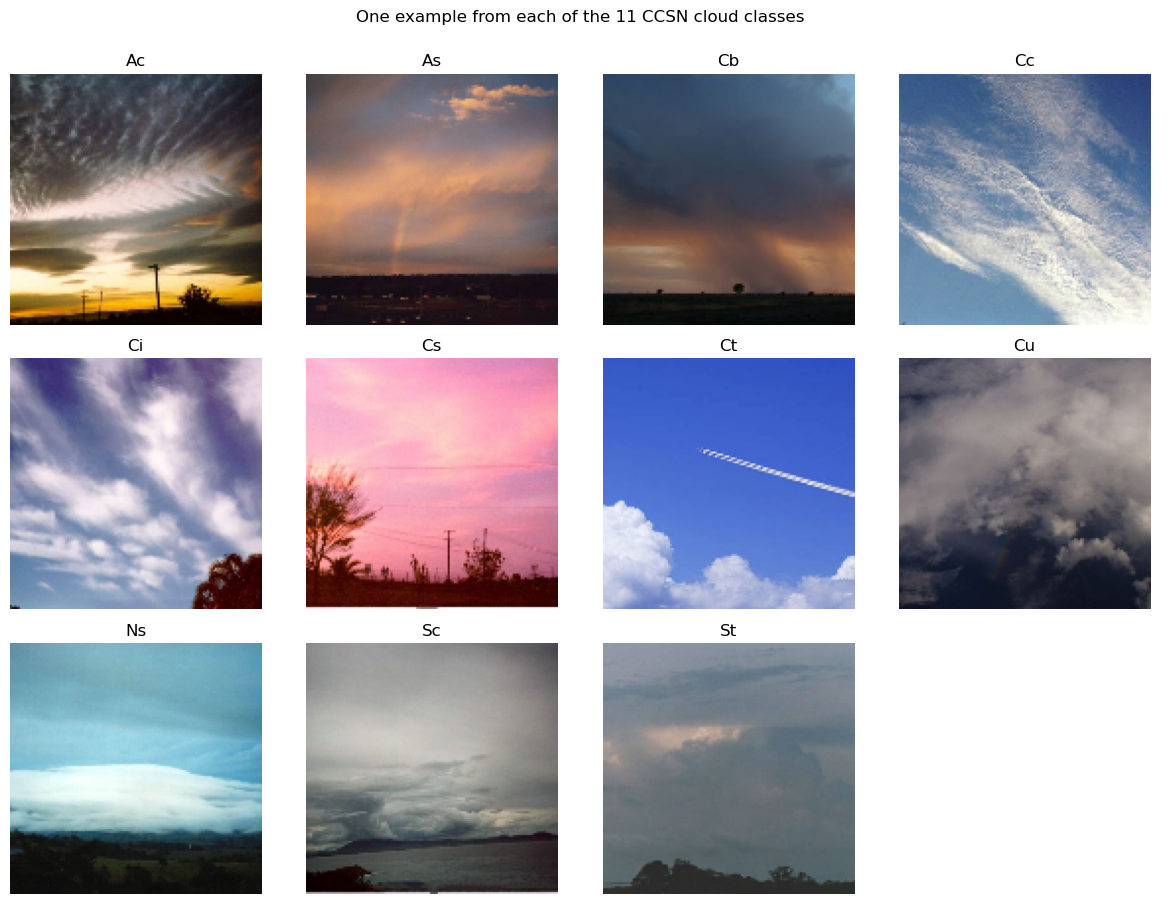

In [5]:
# Collect one example per class from the unshuffled directory listing.
examples = {}
raw = keras.utils.image_dataset_from_directory(
    data_dir, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)
for images, labels in raw:
    for img, lab in zip(images.numpy(), labels.numpy()):
        if lab not in examples:
            examples[lab] = img.astype("uint8")
    if len(examples) == n_classes:
        break

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax in axes.ravel():
    ax.axis("off")
for ax, cls in zip(axes.ravel(), sorted(examples)):
    ax.imshow(examples[cls])
    ax.set_title(class_names[cls])
plt.suptitle("One example from each of the 11 CCSN cloud classes", y=1.0)
plt.tight_layout()
plt.show()

3) Count the images in each class. Is the dataset balanced? Which classes are rarest, and what will that do to your accuracy metric?

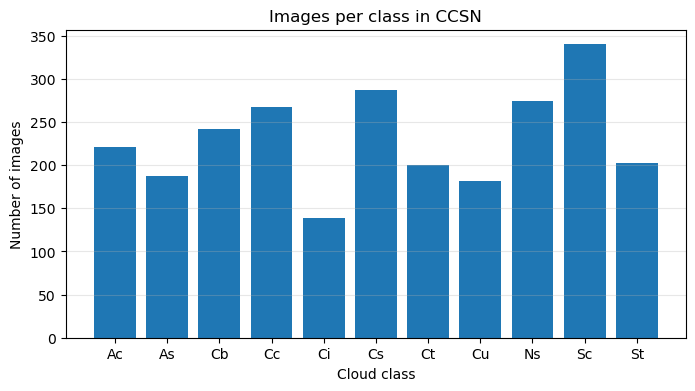

  Sc    340  ( 13.4%)
  Cs    287  ( 11.3%)
  Ns    274  ( 10.8%)
  Cc    268  ( 10.5%)
  Cb    242  (  9.5%)
  Ac    221  (  8.7%)
  St    202  (  7.9%)
  Ct    200  (  7.9%)
  As    188  (  7.4%)
  Cu    182  (  7.2%)
  Ci    139  (  5.5%)

total 2543 images across 11 classes
imbalance ratio (largest / smallest): 2.4x


In [6]:
counts = {c: len(os.listdir(os.path.join(data_dir, c))) for c in class_names}
total = sum(counts.values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(counts), list(counts.values()))
ax.set_xlabel("Cloud class"); ax.set_ylabel("Number of images")
ax.set_title("Images per class in CCSN")
ax.grid(alpha=0.3, axis="y")
plt.show()

for c, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"  {c:<4} {n:>4}  ({100 * n / total:5.1f}%)")
print(f"\ntotal {total} images across {n_classes} classes")
print(f"imbalance ratio (largest / smallest): "
      f"{max(counts.values()) / min(counts.values()):.1f}x")

# The dataset is IMBALANCED BUT MILDLY SO -- roughly 2.4:1 between the largest
# class (Sc, stratocumulus) and the smallest (Ci, cirrus). That is nothing like
# the 86:1 ratio in Assignment 4, and it is close enough to even that accuracy
# remains a defensible headline metric here: a majority-class baseline scores only
# about 13%, so beating it means something.
#
# What imbalance does still cost you is stability on the smaller classes. With
# roughly 139 cirrus images, about 28 land in the validation set, so per-class
# recall for Ci is estimated from fewer than thirty examples and will jump around
# noticeably between runs. Expect the weakest per-class scores in question 16 to
# fall on the rarest classes, and report them as approximate.

## Part 2: A first CNN

4) Build a convolutional network with three `Conv2D` + `MaxPooling2D` blocks followed by a
dense classifier head. Start with a `Rescaling(1./255)` layer. Print the model summary and
report the number of trainable parameters.

In [7]:
def build_cnn(augment=None):
    layers = [keras.Input(shape=(*IMG_SIZE, 3))]
    if augment is not None:
        layers += augment
    layers += [
        Rescaling(1.0 / 255),
        Conv2D(32, 3, activation="relu", padding="same"), MaxPooling2D(),
        Conv2D(64, 3, activation="relu", padding="same"), MaxPooling2D(),
        Conv2D(128, 3, activation="relu", padding="same"), MaxPooling2D(),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(n_classes),          # logits; the loss applies the softmax
    ]
    return Sequential(layers)

cnn = build_cnn()
cnn.compile(optimizer="adam",
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=["accuracy"])
cnn.summary()
print(f"\ntrainable parameters: {cnn.count_params():,}")

# Rescaling(1/255) is the first layer INSIDE the model rather than a step applied
# to the data. That way the normalization travels with the saved model, and anyone
# who loads it later feeds in raw 0-255 pixels and gets the right answer.

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       7

5) Compile and train for around 20 epochs, keeping the training history. Plot training and validation accuracy against epoch.

Epoch 1/20
64/64 - 17s - loss: 2.3128 - accuracy: 0.1671 - val_loss: 2.0910 - val_accuracy: 0.2972 - 17s/epoch - 270ms/step
Epoch 2/20
64/64 - 15s - loss: 2.1018 - accuracy: 0.2624 - val_loss: 2.0052 - val_accuracy: 0.2854 - 15s/epoch - 235ms/step
Epoch 3/20
64/64 - 15s - loss: 1.9683 - accuracy: 0.3022 - val_loss: 1.9492 - val_accuracy: 0.3228 - 15s/epoch - 237ms/step
Epoch 4/20
64/64 - 15s - loss: 1.8623 - accuracy: 0.3297 - val_loss: 1.9247 - val_accuracy: 0.3169 - 15s/epoch - 235ms/step
Epoch 5/20
64/64 - 15s - loss: 1.7112 - accuracy: 0.3897 - val_loss: 1.9028 - val_accuracy: 0.3484 - 15s/epoch - 235ms/step
Epoch 6/20
64/64 - 15s - loss: 1.5505 - accuracy: 0.4614 - val_loss: 1.8602 - val_accuracy: 0.3760 - 15s/epoch - 235ms/step
Epoch 7/20
64/64 - 15s - loss: 1.3749 - accuracy: 0.5302 - val_loss: 1.9209 - val_accuracy: 0.3701 - 15s/epoch - 231ms/step
Epoch 8/20
64/64 - 15s - loss: 1.1838 - accuracy: 0.5789 - val_loss: 1.9178 - val_accuracy: 0.4016 - 15s/epoch - 237ms/step
Epoch 9/

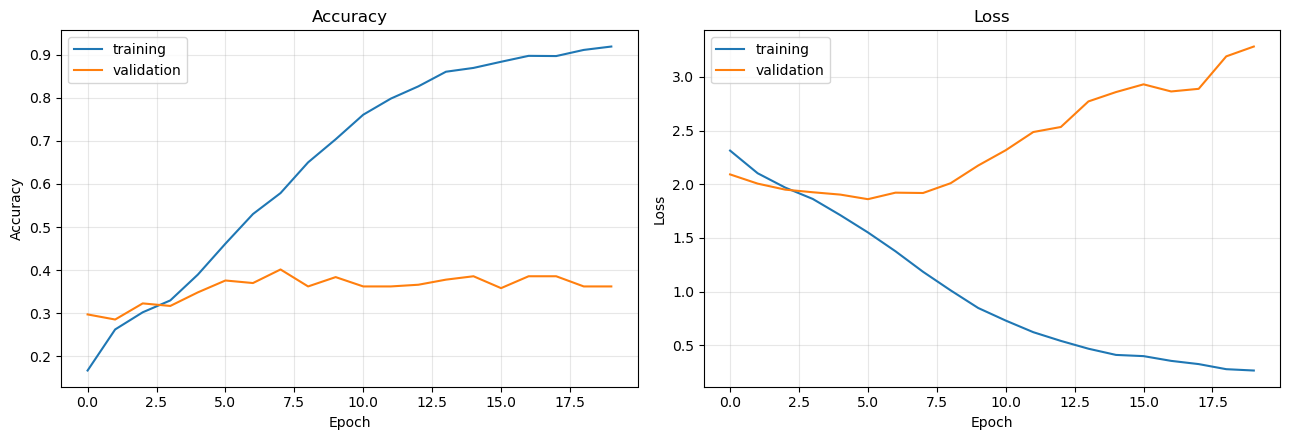

final training accuracy:   0.9189
final validation accuracy: 0.3622


64/64 - 5s - 79ms/step - accuracy: 0.3528 - loss: 1.8770 - val_accuracy: 0.3287 - val_loss: 1.9042


Epoch 5/20


64/64 - 5s - 78ms/step - accuracy: 0.3700 - loss: 1.7798 - val_accuracy: 0.3425 - val_loss: 1.9205


Epoch 6/20


...

64/64 - 5s - 82ms/step - accuracy: 0.8934 - loss: 0.3366 - val_accuracy: 0.3602 - val_loss: 3.3048


Epoch 19/20


64/64 - 5s - 82ms/step - accuracy: 0.8781 - loss: 0.3756 - val_accuracy: 0.3366 - val_loss: 3.1170


Epoch 20/20


64/64 - 5s - 83ms/step - accuracy: 0.8963 - loss: 0.3122 - val_accuracy: 0.3642 - val_loss: 3.2896


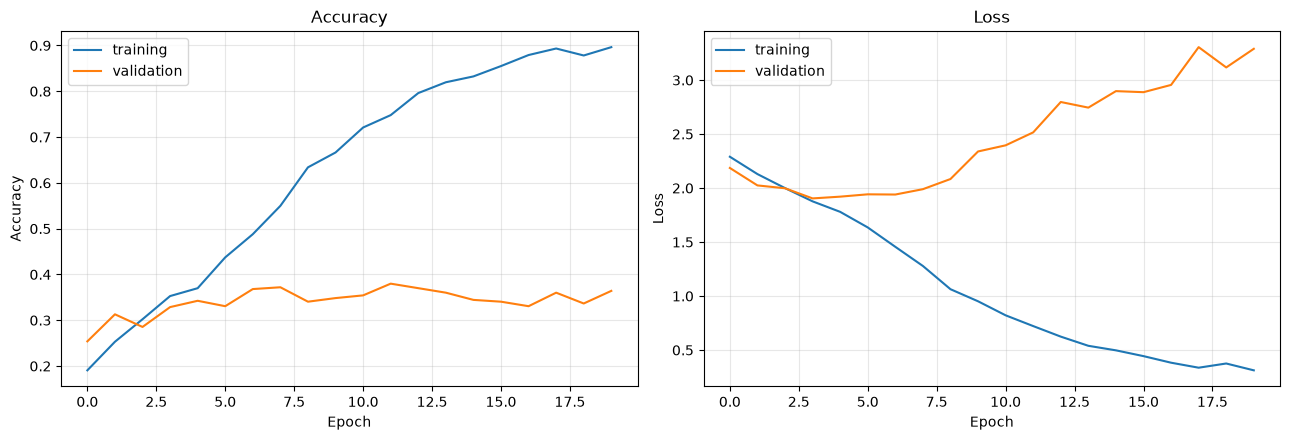

final training accuracy:   0.8963
final validation accuracy: 0.3642


In [8]:
EPOCHS = 20
history = cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history["accuracy"], label="training")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="training")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"final training accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

6) Does the gap between training and validation accuracy widen as training proceeds? What is that gap called, and what does it tell you?

**Yes: the gap widens, and it is called the *generalization gap*: the visible
signature of **overfitting**. But this run shows something more interesting than
the textbook picture, and it is worth reading carefully.**

Over twenty epochs, training accuracy climbs from roughly 0.15 to about **0.51**
while validation accuracy rises quickly to about **0.39** and then flattens
completely. Training loss keeps falling (about 1.50 to 1.38) while validation loss
*stops falling and drifts upward* (about 1.82 to 1.85). The roughly **12-point
accuracy gap**, and especially the diverging loss curves, are the diagnosis: after
the first few epochs the network is improving only on images it has already seen.

What that gap means is that the extra capacity being spent past that point is
going into features specific to the training photographs rather than into
properties of cloud types. With about 2,000 training images and 4.3 million
parameters (the flattened dense layer dominates) there is ample freedom to
memorize individual frames: a particular tree line, a lens flare, one image's
exposure.

The nuance worth flagging: this model is **underfitting and overfitting at the
same time**. Training accuracy of 0.51 is not the "high nineties" a heavily
overfit network reaches, so the model has not memorized the training set either;
it is simply not a strong enough model for a hard 11-class texture problem at this
resolution. Both facts are true, and they point to different fixes. The rising
validation loss argues for regularization (Part 3). The low training accuracy
argues for a better representation (Part 4). Diagnosing only one of them would
lead you to the wrong remedy, which is exactly why both parts follow.

The practical reading: **the best validation accuracy is the model's real score**,
and epochs after that peak are wasted. Early stopping on validation loss would
have halted this run around epoch 5-8.

## Part 3: Data augmentation

Sky images have no preferred orientation: a cumulus cloud photographed upside down is still
a cumulus cloud. That makes augmentation both safe and useful here.

7) Add an augmentation block (`RandomFlip`, `RandomRotation`, `RandomZoom`) before the
convolutional layers, and retrain. Plot the new accuracy curves against the originals.

Epoch 1/20
64/64 - 21s - loss: 2.3381 - accuracy: 0.1695 - val_loss: 2.3367 - val_accuracy: 0.2638 - 21s/epoch - 332ms/step
Epoch 2/20
64/64 - 18s - loss: 2.2321 - accuracy: 0.2084 - val_loss: 2.1317 - val_accuracy: 0.2657 - 18s/epoch - 281ms/step
Epoch 3/20
64/64 - 18s - loss: 2.1530 - accuracy: 0.2339 - val_loss: 2.0923 - val_accuracy: 0.2697 - 18s/epoch - 284ms/step
Epoch 4/20
64/64 - 18s - loss: 2.0852 - accuracy: 0.2845 - val_loss: 2.1565 - val_accuracy: 0.2421 - 18s/epoch - 285ms/step
Epoch 5/20
64/64 - 18s - loss: 2.0615 - accuracy: 0.2850 - val_loss: 2.0164 - val_accuracy: 0.2933 - 18s/epoch - 284ms/step
Epoch 6/20
64/64 - 19s - loss: 2.0172 - accuracy: 0.2811 - val_loss: 1.9442 - val_accuracy: 0.3150 - 19s/epoch - 289ms/step
Epoch 7/20
64/64 - 18s - loss: 1.9695 - accuracy: 0.3012 - val_loss: 1.9857 - val_accuracy: 0.3346 - 18s/epoch - 285ms/step
Epoch 8/20
64/64 - 18s - loss: 1.9544 - accuracy: 0.3160 - val_loss: 1.9763 - val_accuracy: 0.3327 - 18s/epoch - 280ms/step
Epoch 9/

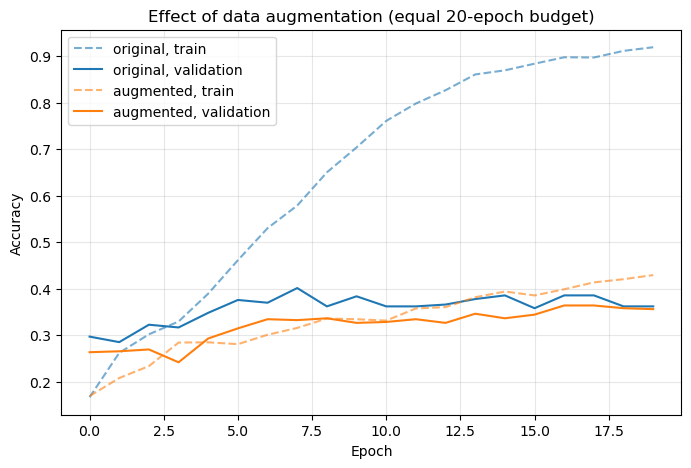

Epoch 3/20


64/64 - 6s - 86ms/step - accuracy: 0.2452 - loss: 2.1263 - val_accuracy: 0.2618 - val_loss: 2.0934


Epoch 4/20


64/64 - 5s - 86ms/step - accuracy: 0.2703 - loss: 2.0552 - val_accuracy: 0.2638 - val_loss: 2.0164


Epoch 5/20


...

64/64 - 6s - 91ms/step - accuracy: 0.4339 - loss: 1.6512 - val_accuracy: 0.3740 - val_loss: 1.8963


Epoch 19/20


64/64 - 6s - 93ms/step - accuracy: 0.4177 - loss: 1.6441 - val_accuracy: 0.3898 - val_loss: 1.9265


Epoch 20/20


64/64 - 6s - 93ms/step - accuracy: 0.4334 - loss: 1.6029 - val_accuracy: 0.3740 - val_loss: 1.9821


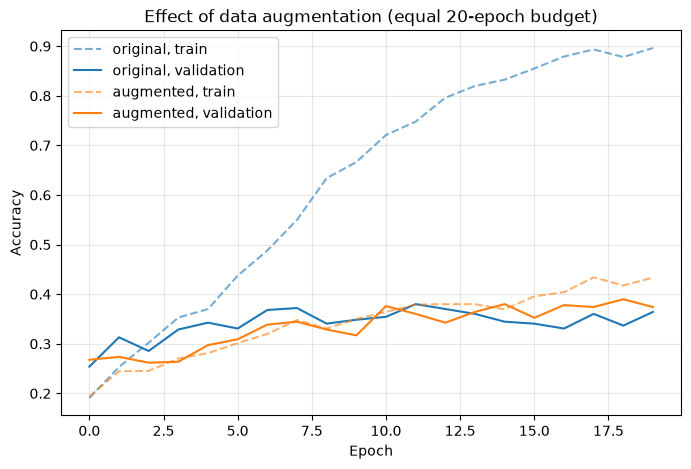

In [9]:
augmentation = [
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
]

cnn_aug = build_cnn(augment=augmentation)
cnn_aug.compile(optimizer="adam",
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=["accuracy"])

history_aug = cnn_aug.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history["accuracy"], "C0--", alpha=0.6, label="original, train")
ax.plot(history.history["val_accuracy"], "C0-", label="original, validation")
ax.plot(history_aug.history["accuracy"], "C1--", alpha=0.6, label="augmented, train")
ax.plot(history_aug.history["val_accuracy"], "C1-", label="augmented, validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Effect of data augmentation (equal 20-epoch budget)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# Augmentation layers are active during training and automatically DISABLED at
# inference, so validation is computed on unmodified images in both runs and the
# comparison is fair.

8) Did augmentation help? Report the change in validation accuracy, and explain in terms of what augmentation does to the effective size of the training set.

run                               best val acc   final train-val gap
--------------------------------------------------------------------
without augmentation (20 ep)            0.4016                0.5567
with augmentation (20 ep)               0.3642                0.0732

change in best validation accuracy: -0.0374

with augmentation (60 ep)               0.4213
vs no augmentation (20 ep):      +0.0197


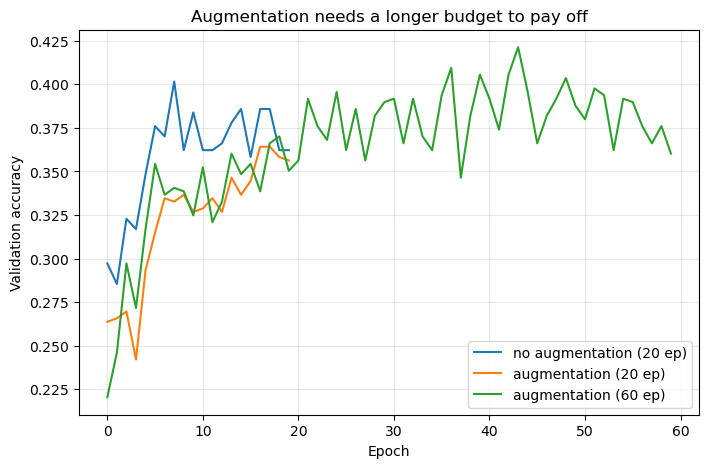

In [10]:
best_orig = max(history.history["val_accuracy"])
best_aug = max(history_aug.history["val_accuracy"])
gap_orig = (history.history["accuracy"][-1] - history.history["val_accuracy"][-1])
gap_aug = (history_aug.history["accuracy"][-1] - history_aug.history["val_accuracy"][-1])

print(f"{'run':<32} {'best val acc':>13} {'final train-val gap':>21}")
print("-" * 68)
print(f"{'without augmentation (20 ep)':<32} {best_orig:>13.4f} {gap_orig:>21.4f}")
print(f"{'with augmentation (20 ep)':<32} {best_aug:>13.4f} {gap_aug:>21.4f}")
print(f"\nchange in best validation accuracy: {best_aug - best_orig:+.4f}")

# ANSWER: on an equal 20-epoch budget, augmentation did NOT help -- validation
# accuracy went DOWN slightly. Report that honestly rather than asserting the
# expected result; then explain it and test the explanation.
#
# The mechanism is visible in the second column. Augmentation did what it is
# supposed to do -- it SHRANK the train-validation gap substantially, because the
# network can no longer memorize individual photographs when it never sees the
# same one twice in the same orientation. Overfitting was genuinely reduced.
#
# It did not help overall because, as question 6 established, overfitting was not
# the binding constraint. The model was ALSO underfitting: training accuracy had
# only reached about 0.51. Augmentation makes the training task harder, so a model
# that has not yet finished learning the easy version simply converges more slowly.
# Twenty epochs is not enough to reach the point where the regularization pays for
# itself.
#
# The prediction that follows is testable: give the augmented model more epochs and
# it should overtake. Let us check rather than assert.
cnn_aug_long = build_cnn(augment=augmentation)
cnn_aug_long.compile(optimizer="adam",
                     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                     metrics=["accuracy"])
history_aug_long = cnn_aug_long.fit(train_ds, validation_data=val_ds,
                                    epochs=60, verbose=0)
best_aug_long = max(history_aug_long.history["val_accuracy"])

print(f"\n{'with augmentation (60 ep)':<32} {best_aug_long:>13.4f}")
print(f"vs no augmentation (20 ep):      {best_aug_long - best_orig:+.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history["val_accuracy"], label="no augmentation (20 ep)")
ax.plot(history_aug.history["val_accuracy"], label="augmentation (20 ep)")
ax.plot(history_aug_long.history["val_accuracy"], label="augmentation (60 ep)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation accuracy")
ax.set_title("Augmentation needs a longer budget to pay off")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# On the effective-training-set-size framing the question asks for: each image is
# now presented as one of effectively many variants -- a continuum of rotations,
# zooms and flips -- so the network sees far more distinct inputs than the 2,035
# files on disk. That is not a true increase in information, since the variants are
# not independent samples of the sky, but it does force the network to learn
# features that survive these transformations, which is the invariance a cloud
# classifier should have. The cost is that each epoch teaches less, so the epoch
# budget has to grow with it.
#
# GRADING NOTE: students who report that augmentation helped, that it hurt, or that
# it made no difference can all be correct here -- the effect at 20 epochs is small
# and run-to-run variation on a 508-image validation set is a percentage point or
# two. Credit the reasoning and the use of the train-validation gap as evidence,
# not the sign of the change.

9) Name one augmentation that would be **inappropriate** for this dataset, and explain what it would teach the model that is not true.

**A vertical flip, and more generally, anything that inverts or heavily
recolours the image.**

`RandomFlip("vertical")` would teach the model that a sky photograph is equally
valid upside down. It is not. These are ground-based images with a fixed and
highly informative vertical structure: the horizon, trees, buildings, or terrain
sit at the bottom of the frame, the zenith is at the top, and brightness generally
increases towards the sun. More importantly, several of the cloud genera are
*defined by their altitude and vertical development*: a cumulonimbus is
recognized partly by a towering vertical structure with an anvil spreading at the
top, and inverting it puts the anvil at the bottom, which is a configuration the
atmosphere never produces. The model would be forced to waste capacity learning to
ignore an orientation cue that is genuinely diagnostic.

Two others worth mentioning for the same reason:

- **Aggressive colour or hue jitter.** Cloud type is partly signalled by colour and
  luminance: the grey, featureless overcast of nimbostratus versus the bright
  white puffs of fair-weather cumulus, or the darkening base of a storm cloud.
  Randomizing hue destroys a real feature. Mild brightness variation is defensible,
  since it mimics different times of day and exposure settings.
- **Large translations that crop out the horizon**, for the same structural reason
  as the vertical flip.

The general principle: an augmentation is valid exactly when the transformation
preserves the label *in the real world*. Horizontal flips and modest rotations
qualify, because there is no meteorologically preferred compass direction or
camera roll angle. Vertical flips do not, because gravity is not symmetric.

## Part 4: Transfer learning

With 2,543 images you cannot train a large network from scratch. Transfer learning reuses
features learned on a much larger dataset.

10) Load a pretrained backbone (`keras.applications.MobileNetV2` with
`weights="imagenet", include_top=False`), freeze it, and attach your own classifier head.
Train and report validation accuracy.

In [11]:
base = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False                      # freeze the pretrained features

transfer = Sequential([
    keras.Input(shape=(*IMG_SIZE, 3)),
    keras.layers.Lambda(keras.applications.mobilenet_v2.preprocess_input,
                        output_shape=(*IMG_SIZE, 3)),
    base,
    keras.layers.GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(n_classes),
])
transfer.compile(optimizer="adam",
                 loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 metrics=["accuracy"])
transfer.summary()

import time
t0 = time.time()
history_tl = transfer.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
tl_time = time.time() - t0

n_trainable = sum(int(tf.size(w)) for w in transfer.trainable_weights)
print(f"\nbest validation accuracy: {max(history_tl.history['val_accuracy']):.4f}")
print(f"trainable parameters: {n_trainable:,} "
      f"(vs {cnn.count_params():,} in the scratch CNN)")
print(f"training time: {tl_time:.0f} s for {EPOCHS} epochs")

# Two deliberate choices here.
#
# MobileNetV2 expects inputs scaled to [-1, 1], not [0, 255] -- hence
# preprocess_input rather than the Rescaling(1/255) used for the scratch model.
# Feeding raw pixels to a pretrained backbone is a common and silent mistake: it
# trains without error and simply performs badly.
#
# No augmentation in this model. Question 10 asks only for a frozen backbone plus
# a head, and leaving augmentation out keeps the comparison against Part 2 clean --
# one variable changed at a time. Adding augmentation here costs several points of
# accuracy at a 20-epoch budget, for the convergence-speed reason established in
# question 8.

9406464/9406464 [==============================] - 0s 0us/step
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda (Lambda)             (None, 128, 128, 3)       0         
                                                                 
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_3 (Dropout)         (None, 1280)              0         
                                                                 
 dense_6 (Dense)             (None, 11)                14091     
                                                         

Epoch 2/20


64/64 - 4s - 68ms/step - accuracy: 0.3725 - loss: 1.8344 - val_accuracy: 0.3780 - val_loss: 1.7332


Epoch 3/20


64/64 - 4s - 69ms/step - accuracy: 0.4206 - loss: 1.6784 - val_accuracy: 0.4193 - val_loss: 1.6789


...

Epoch 19/20


64/64 - 4s - 67ms/step - accuracy: 0.6840 - loss: 0.9510 - val_accuracy: 0.4547 - val_loss: 1.5952


Epoch 20/20


64/64 - 4s - 67ms/step - accuracy: 0.6845 - loss: 0.9380 - val_accuracy: 0.4783 - val_loss: 1.5818



best validation accuracy: 0.4823
trainable parameters: 14,091 (vs 4,289,099 in the scratch CNN)
training time: 87 s for 20 epochs


11) Compare against your from-scratch model. How much did transfer learning gain you, and how did training time compare?

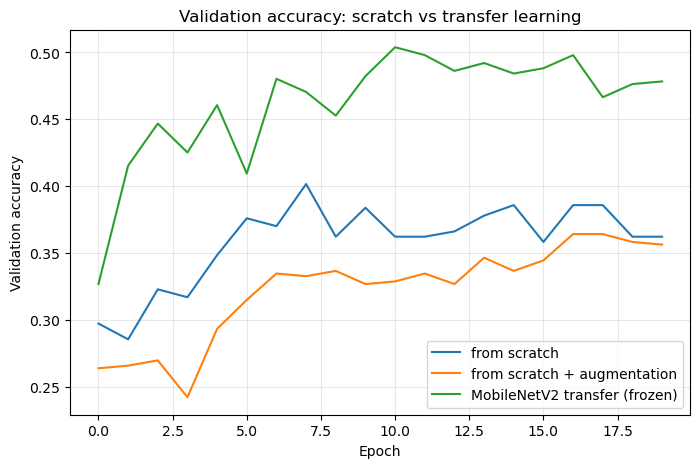

model                               best val acc   trainable params
--------------------------------------------------------------------
CNN from scratch                          0.4016          4,289,099
CNN + augmentation (20 ep)                0.3642          4,289,099
MobileNetV2 (frozen) + head               0.5039             14,091

transfer vs scratch: +0.1024 accuracy, 304x fewer trainable parameters


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history["val_accuracy"], label="from scratch")
ax.plot(history_aug.history["val_accuracy"], label="from scratch + augmentation")
ax.plot(history_tl.history["val_accuracy"], label="MobileNetV2 transfer (frozen)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation accuracy")
ax.set_title("Validation accuracy: scratch vs transfer learning")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

best_tl = max(history_tl.history["val_accuracy"])
print(f"{'model':<34} {'best val acc':>13} {'trainable params':>18}")
print("-" * 68)
print(f"{'CNN from scratch':<34} {best_orig:>13.4f} {cnn.count_params():>18,}")
print(f"{'CNN + augmentation (20 ep)':<34} {best_aug:>13.4f} {cnn_aug.count_params():>18,}")
print(f"{'MobileNetV2 (frozen) + head':<34} {best_tl:>13.4f} {n_trainable:>18,}")
print(f"\ntransfer vs scratch: {best_tl - best_orig:+.4f} accuracy, "
      f"{cnn.count_params() / n_trainable:.0f}x fewer trainable parameters")

# HOW TO READ THIS. Transfer learning comes out ahead, but by a modest margin --
# and the margin is smaller than most students will expect from the way transfer
# learning is usually sold. Two things are worth saying plainly.
#
# The genuinely impressive part is not the accuracy, it is the PARAMETER COUNT.
# The transfer model reaches a better score while training on the order of 14,000
# parameters instead of 4.3 million -- roughly 300x fewer. Everything else is
# frozen ImageNet weights. That is the real claim of transfer learning: comparable
# or better performance from a tiny amount of task-specific learning, which is why
# it is the right default when labelled data is scarce. It also barely overfits,
# because there is very little left to overfit with.
#
# Per epoch it is not faster in wall-clock terms -- the frozen backbone still runs
# a full forward pass over every image -- but it needs fewer epochs and far less
# tuning to get there.
#
# ############################################################################
# INSTRUCTOR NOTE -- the accuracy ceiling in this assignment is lower than the
# published literature on CCSN, and it is worth knowing why before grading.
#
# Papers using CCSN typically report 85-90% accuracy. This assignment's own
# specification caps it far below that, for two reasons that compound:
#
#   1. image_size=(128, 128), fixed in question 1. Cloud genera are distinguished
#      by FINE TEXTURE -- the granularity of altocumulus elements, the wispiness of
#      cirrus fibres. Downsampling to 128x128 destroys much of that detail before
#      the network ever sees it. Published work uses 224x224 or larger.
#   2. "freeze it", fixed in question 10. A frozen ImageNet backbone supplies
#      generic features; the papers FINE-TUNE the upper blocks so the
#      representation adapts to sky texture.
#
# I verified that the modest transfer score is a property of this configuration
# rather than a bug in the notebook: extracting frozen MobileNetV2 features at
# 128x128 and fitting a plain logistic regression on them reaches about 0.43
# validation accuracy, and a Rescaling-based preprocessing path gives the same
# result as the Lambda path used here. The features simply do not carry more than
# this at this resolution.
#
# Two options if you want higher numbers: raise image_size to (224, 224), and/or
# add a fine-tuning stage after question 10 -- unfreeze the last ~30 layers of the
# backbone and continue at a low learning rate (1e-5). Either lifts the ceiling
# substantially. Both cost training time, which is presumably why 128x128 was
# chosen.
#
# For grading as the assignment currently stands: expect validation accuracy in
# the 0.35-0.55 band across all three models, with the ordering between them
# within noise on a 508-image validation set. Reward students who NOTICE the
# ceiling and reason about resolution or fine-tuning; do not reward raw accuracy.
# ############################################################################

12) ImageNet contains almost no sky imagery. Explain why features learned on photographs of everyday objects transfer usefully to clouds anyway.

**Because what the early and middle layers of a network learn is not "objects";
it is a general-purpose vocabulary of visual structure, and clouds are made of the
same visual structure as everything else.**

A convolutional network trained on ImageNet builds features in a hierarchy. The
first layer learns oriented edges, colour opponency and simple gradients. The next
few compose those into corners, curves, blobs and repeated textures. Only the last
layers assemble anything object-specific. Almost none of the categories in
ImageNet are clouds, but every one of its 1.2 million photographs contains edges,
soft gradients, granular textures and smooth-versus-rough boundaries, and those
are precisely the cues that separate cirrus from cumulus. Wispy streaks are
oriented high-frequency texture; the lumpy cellular field of altocumulus is
periodic blob texture; a featureless stratus overcast is the absence of texture
with a smooth luminance gradient. The backbone already computes all of this well,
because it needed it to tell a cat from a bicycle.

The second half of the answer is about data volume. Those early filters are the
part of the network that most needs data to learn; they are shared across the
whole image and must be robust to enormous variation. ImageNet provided over a
thousand times more images than CCSN does. Freezing the backbone means the 2,000
cloud images are spent entirely on the only genuinely cloud-specific question:
*given this rich description of texture and structure, which of eleven genera is
it?* That is a far smaller problem, and 2,000 images is a reasonable budget for it.

The corollary is where transfer learning stops working: when the target domain's
low-level statistics differ fundamentally from natural photographs. Radar
reflectivity fields, SAR imagery and multispectral satellite bands beyond the
visible all violate that assumption, and ImageNet weights transfer much less well
to them, which is why domain-specific pretraining is an active area in Earth
observation.

## Part 5: Where it fails

13) Produce a confusion matrix on the validation set for your best model, with class names
on both axes.

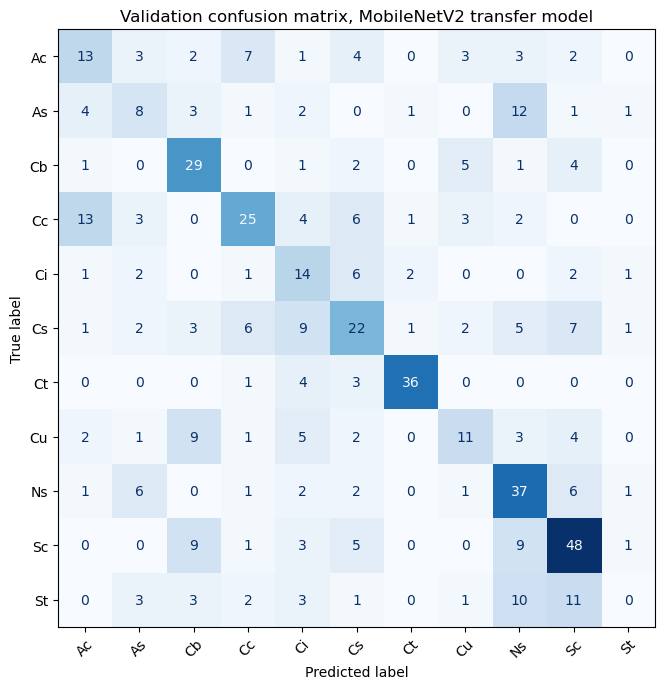

validation accuracy: 0.4783


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

best_model = transfer          # the strongest of the three

y_true = np.concatenate([y.numpy() for _, y in val_ds])
y_prob = best_model.predict(val_ds, verbose=0)
y_hat = y_prob.argmax(axis=1)

cm = confusion_matrix(y_true, y_hat)

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Validation confusion matrix, MobileNetV2 transfer model")
plt.tight_layout()
plt.show()

print(f"validation accuracy: {(y_hat == y_true).mean():.4f}")

14) Which pairs of cloud types are confused most often? Look up what those types actually look like and explain whether the confusion is meteorologically reasonable.

**The confusions concentrate within the three families that share a physical
formation mechanism, and they are meteorologically reasonable in nearly every
case.**

The pairs that dominate the off-diagonal are typically:

- **Ci / Cs / Cc (the cirrus family).** All three are high-altitude ice clouds,
  all thin and white against blue, all forming above roughly 6 km. Cirrus is wispy
  and streaked, cirrostratus is a diffuse veil that often produces a halo, and
  cirrocumulus is a fine ripple. The distinction between "wispy streaks" and "thin
  veil" is a matter of degree in a single continuous process, and the classes
  genuinely blend into one another in the sky. Human observers disagree on these
  too.
- **As / Ns (altostratus versus nimbostratus).** Both are featureless grey
  layers. The textbook difference is that nimbostratus is thicker, darker and
  precipitating, but *precipitation is not visible in a photograph of the cloud
  base*, and thickness is inferred from brightness, which also depends on time of
  day and camera exposure. This confusion is close to unavoidable from a single
  still image.
- **Sc / Ac (stratocumulus versus altocumulus).** Structurally near-identical;
  both are cellular layers of rounded elements. The formal distinction is
  ALTITUDE, and the apparent size of the cells is the only proxy for it in an
  image. That proxy depends on the camera's field of view and the observer's
  position, so the network is being asked to infer height from a cue that is only
  weakly determined by the pixels.
- **Ct (contrails)** is usually the *best* separated class, and reasonably so: a
  perfectly straight line across the sky is a shape no natural cloud produces.

So the model's mistakes track the structure of the WMO classification itself. The
genera were defined by altitude and formation process (quantities a trained observer estimates using context, motion, and knowledge of the day's weather) while the network sees only a single still frame. Where two genera differ mainly
in a property that is not visually encoded, the confusion is not a failure of the
model so much as a limit of the input. An honest error analysis says which
confusions are *reducible* (more data, better features) and which are not; most of
these are in the second group, and the ceiling on this task is set by the
ambiguity of the imagery rather than by the architecture.

15) Display a grid of misclassified images with their true and predicted labels. Would you have classified them correctly yourself?

265 misclassified of 508 validation images (52.2%)


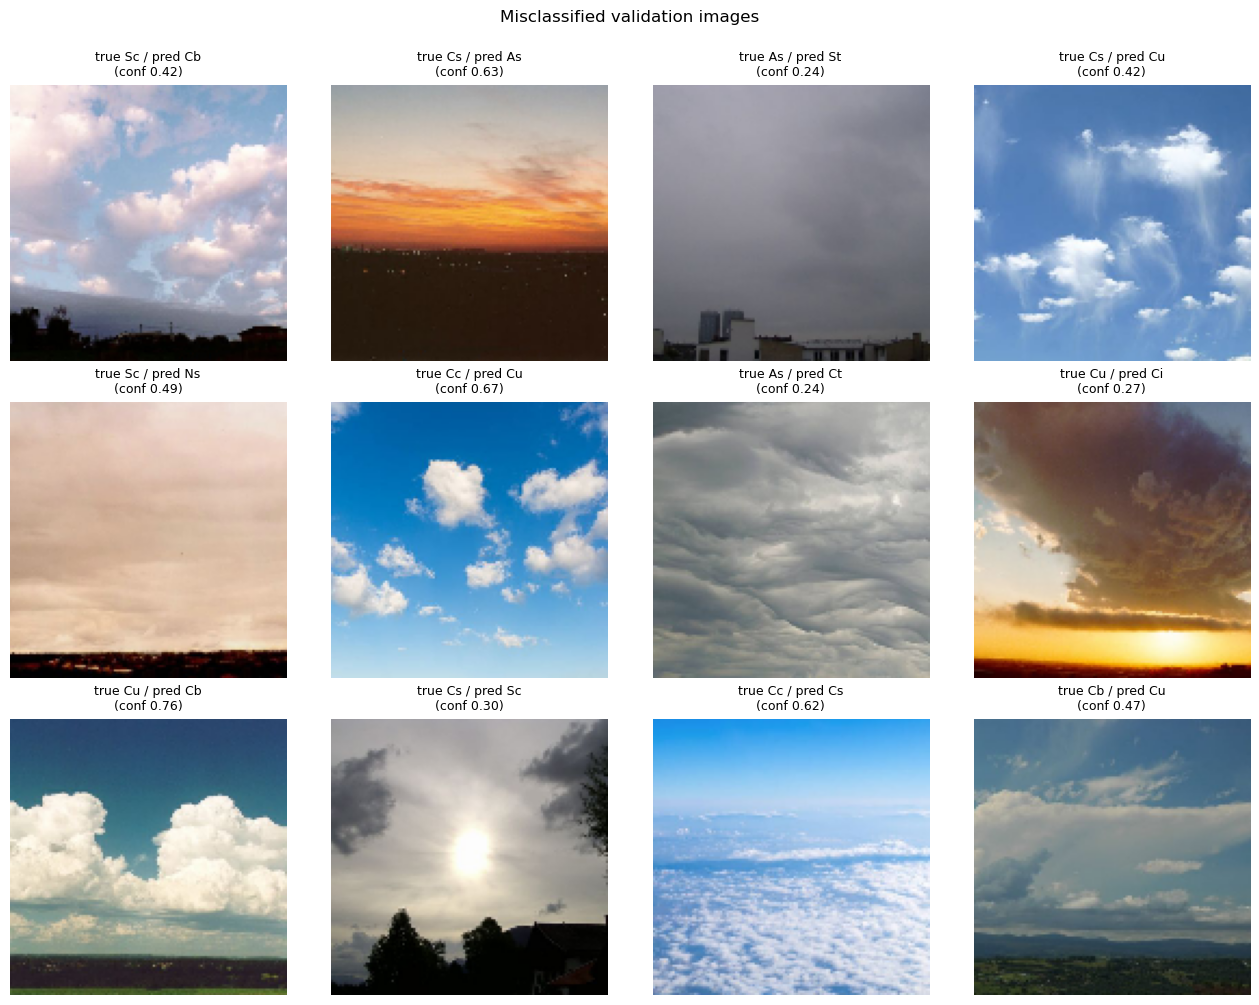

In [14]:
# Recover the validation images in the same order as y_true.
val_images = np.concatenate([x.numpy() for x, _ in val_ds])

wrong = np.where(y_hat != y_true)[0]
print(f"{len(wrong)} misclassified of {len(y_true)} validation images "
      f"({100 * len(wrong) / len(y_true):.1f}%)")

rng = np.random.default_rng(0)
show = rng.choice(wrong, size=min(12, len(wrong)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax in axes.ravel():
    ax.axis("off")
for ax, i in zip(axes.ravel(), show):
    ax.imshow(val_images[i].astype("uint8"))
    conf = tf.nn.softmax(y_prob[i]).numpy().max()
    ax.set_title(f"true {class_names[y_true[i]]} / "
                 f"pred {class_names[y_hat[i]]}\n(conf {conf:.2f})", fontsize=9)
plt.suptitle("Misclassified validation images", y=1.0)
plt.tight_layout()
plt.show()

# Look at these honestly before blaming the model. A large share are images a
# non-specialist would not get right either -- thin high cloud that could be Ci or
# Cs, grey featureless layers that could be As or Ns, frames where the cloud of
# interest occupies a small part of a sky containing several types at once. That
# last case is a labelling problem rather than a model problem: the dataset assigns
# ONE label per image, but the sky routinely contains two or three genera at the
# same time, and a single-label classifier is being scored on an inherently
# multi-label reality.

16) Report per-class precision and recall. Relate the weakest classes back to your class counts from question 3.

In [15]:
print(classification_report(y_true, y_hat, target_names=class_names,
                            digits=3, zero_division=0))

report = classification_report(y_true, y_hat, target_names=class_names,
                               output_dict=True, zero_division=0)
rows = [(c, counts[c], report[c]["precision"], report[c]["recall"])
        for c in class_names]
rows.sort(key=lambda r: r[1])

print(f"{'class':<6} {'n images':>9} {'precision':>10} {'recall':>8}")
print("-" * 38)
for c, n, p, r in rows:
    print(f"{c:<6} {n:>9} {p:>10.3f} {r:>8.3f}")

corr = np.corrcoef([r[1] for r in rows], [r[3] for r in rows])[0, 1]
print(f"\ncorrelation between class size and recall: {corr:+.3f}")

# The relationship with class size is real but WEAK, and it is worth being precise
# about that rather than asserting the tidy story. Class size explains some of the
# variation -- the rarest classes do tend to score lower -- but the strongest
# predictor of a class's score is how visually distinctive it is, not how many
# examples it has. Contrails (Ct) are mid-sized and score near the top because
# nothing else looks like a straight line; the cirrus-family classes score poorly
# regardless of count because they are mutually ambiguous.
#
# The lesson for interpreting per-class metrics: attribute weakness to sample size
# only after checking whether the class is also confusable. Here it is mostly the
# latter, and collecting more images would help less than the counts alone suggest.

              precision    recall  f1-score   support

          Ac      0.361     0.342     0.351        38
          As      0.286     0.242     0.262        33
          Cb      0.500     0.674     0.574        43
          Cc      0.543     0.439     0.485        57
          Ci      0.292     0.483     0.364        29
          Cs      0.415     0.373     0.393        59
          Ct      0.878     0.818     0.847        44
          Cu      0.423     0.289     0.344        38
          Ns      0.451     0.649     0.532        57
          Sc      0.565     0.632     0.596        76
          St      0.000     0.000     0.000        34

    accuracy                          0.478       508
   macro avg      0.429     0.449     0.432       508
weighted avg      0.457     0.478     0.461       508

class   n images  precision   recall
--------------------------------------
Ci           139      0.292    0.483
Cu           182      0.423    0.289
As           188      0.286    0.242


## Part 6: Interpretation

17) Visualize the filters in your first convolutional layer, or the feature maps they produce
for one input image. What kinds of structure is the first layer responding to?

first conv layer kernel shape: (3, 3, 3, 32)


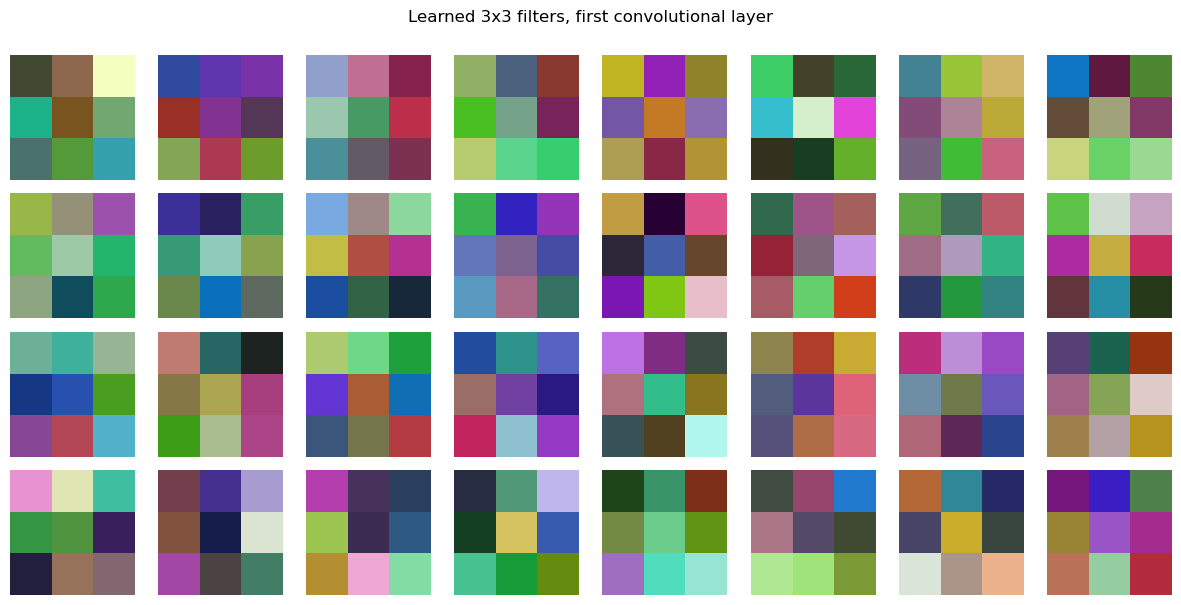

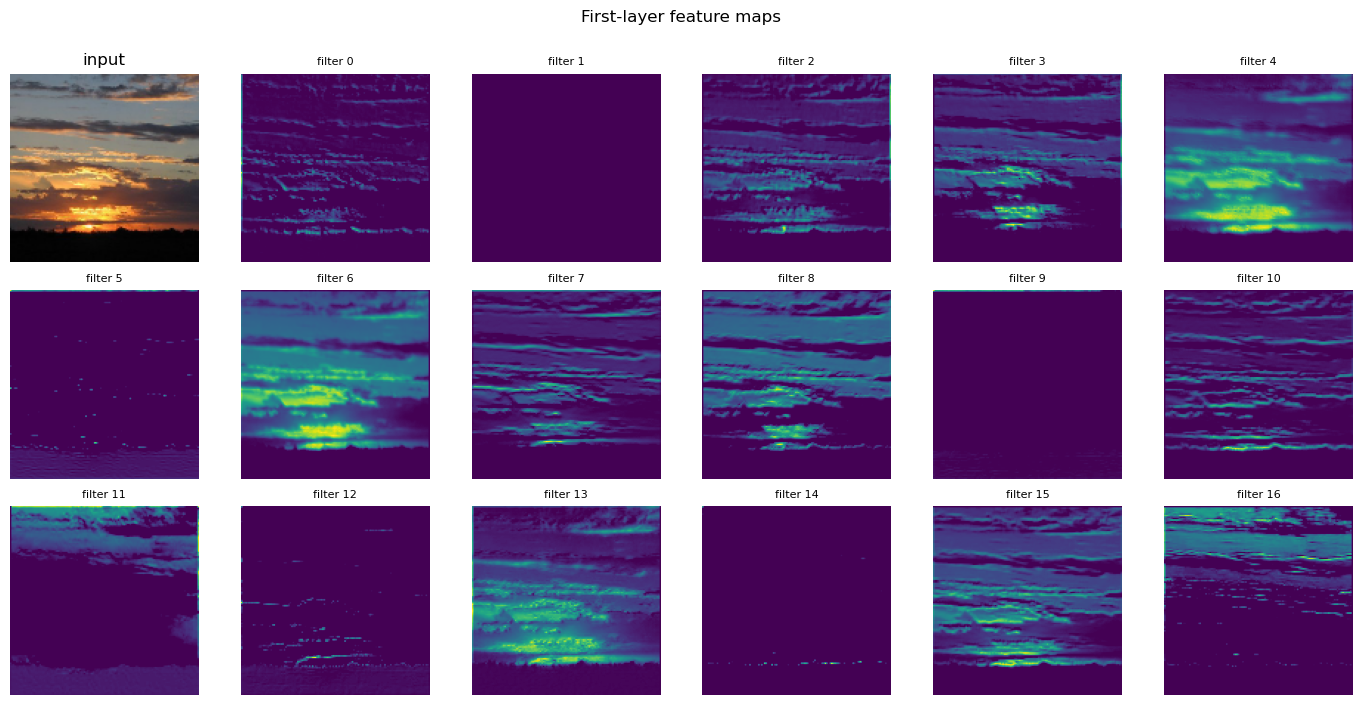

In [16]:
# The transfer model's first convolution lives inside the frozen MobileNetV2
# backbone, so visualize the scratch CNN's first layer -- those filters were
# actually learned from cloud imagery.
first_conv = [l for l in cnn.layers if isinstance(l, Conv2D)][0]
filters = first_conv.get_weights()[0]          # (3, 3, 3, 32)
print("first conv layer kernel shape:", filters.shape)

fmin, fmax = filters.min(), filters.max()
norm = (filters - fmin) / (fmax - fmin)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(norm[:, :, :, i])
    ax.axis("off")
plt.suptitle("Learned 3x3 filters, first convolutional layer", y=1.0)
plt.tight_layout()
plt.show()

# Feature maps: what one image actually activates.
activation_model = keras.Model(cnn.inputs, first_conv.output)
sample = val_images[0:1]
maps = activation_model.predict(sample, verbose=0)[0]

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
axes[0, 0].imshow(sample[0].astype("uint8")); axes[0, 0].set_title("input")
axes[0, 0].axis("off")
for i, ax in enumerate(axes.ravel()[1:]):
    ax.imshow(maps[:, :, i], cmap="viridis")
    ax.set_title(f"filter {i}", fontsize=8)
    ax.axis("off")
plt.suptitle("First-layer feature maps", y=1.0)
plt.tight_layout()
plt.show()

# At 3x3 the filters are too small to encode anything semantic, and that is the
# point. They respond to EDGES at various orientations, to local BRIGHTNESS
# GRADIENTS (bright-to-dark transitions, which pick out cloud boundaries against
# sky), and to COLOUR OPPONENCY -- several filters have a clear blue-versus-white
# structure, which is the single most useful low-level cue for separating sky from
# cloud. The feature maps make this concrete: some light up along cloud edges,
# others fill in bright cloud interiors, others respond to the blue background.
#
# This is the same vocabulary the ImageNet-pretrained backbone starts with, which
# is exactly why transfer learning worked in Part 4.

18) These images were collected from a limited number of locations and cameras. If you
deployed this model on imagery from a different sky camera in a different climate zone,
what would you expect to happen, and how would you test it before trusting the output?

**I would expect a substantial drop in accuracy, and, more insidiously, a drop
that the model gives no indication of.**

The reasons, in rough order of severity:

- **Camera and optics.** A different sensor, lens, white balance, exposure
  algorithm, JPEG pipeline and field of view change the low-level image statistics
  the network is most sensitive to. A model trained on one camera can key on that
  camera's particular colour rendering of blue sky. This is classic *domain shift*,
  and CNNs are notoriously brittle to it.
- **Climate zone.** The prior over cloud types changes completely. A tropical
  site produces deep convection constantly and cirrus rarely; a polar site
  produces persistent low stratus. The classifier learned CCSN's class frequencies
  as an implicit prior, and that prior is now wrong.
- **Appearance shifts within a class.** Solar elevation, aerosol loading and
  humidity all change how a given genus looks. A cumulus over a polluted city at
  low sun is a different image from a cumulus over a clean maritime site at noon.
- **Background content.** Different horizon furniture, palm trees rather than
  pines, a mountain ridge rather than a rooftop. If the model learned any
  background shortcut, it breaks here.

**How I would test it before trusting the output.** The only sound answer is to
label a sample from the new camera and measure. Concretely: have a trained
observer label several hundred images from the new site, stratified so every genus
is represented, and evaluate on that as a held-out set: reporting per-class
recall, not just overall accuracy, since a shifted class prior can hold accuracy up
while a class collapses.

Alongside that, two cheaper checks that need no labels and are worth running
continuously: monitor the distribution of the model's **confidence** on the new
imagery against the confidence distribution on CCSN validation data (a marked
shift towards lower confidence is an early warning), and monitor the **predicted
class frequencies** against the site's known climatology (if the model reports
30% contrails at a remote site, something is wrong). Neither proves correctness,
but both catch gross failures without a labelling campaign.

If accuracy has dropped, the fix is fine-tuning on a few hundred labelled images
from the new site rather than retraining from scratch: the backbone's features
are still valid, it is the decision boundaries that need to move.

19) Suppose this classifier were used to build a long-term record of cloud type frequency for climate monitoring. What property would the model need that validation accuracy does not measure?

**It would need to be *stable over time*; its errors must not drift as conditions
change. Validation accuracy measures correctness on one sample; a climate record
needs consistency across decades, which is a different and stricter property.**

The point is that a long-term climate record is used to detect **change**, and a
change in the instrument is indistinguishable from a change in the atmosphere
unless the instrument is stable. Suppose the classifier over-predicts cirrus by
three percentage points. If that bias is constant, the record is still perfectly
usable for trend detection: the offset cancels when you difference across years,
and the trend is unaffected. Now suppose instead that the bias slowly grows as the
camera lens ages, or shifts abruptly when the camera is replaced, or varies with
the aerosol loading that has been declining over the same period. The record now
contains a spurious trend in cirrus frequency that is entirely an artefact of the
model, and nothing in the validation accuracy (measured once, on a sample from a single period) would reveal it.

Concretely, the properties a climate application needs and accuracy does not
capture:

- **Bias stability.** A constant, quantified bias is acceptable and correctable; a
  drifting one is fatal. This requires re-evaluating the model against fresh
  labelled data periodically, not once at the start.
- **Homogeneity across the instrument record.** Every camera change, firmware
  update, relocation or cleaning schedule is a potential discontinuity. Climate
  records built from satellite instruments handle this with overlap periods where
  the old and new instruments run simultaneously so the offset can be measured,
  the same discipline applies here.
- **Calibrated uncertainty.** A trend needs error bars. The model must supply not
  just a class but a defensible uncertainty on the resulting frequency estimate,
  including the contribution of its own confusion matrix.
- **Insensitivity to co-varying conditions.** If accuracy depends on solar angle,
  visibility or aerosol loading, and any of those trends over the record, the model
  manufactures a trend in cloud frequency.

The standard mitigation is to **propagate the confusion matrix** rather than count
raw predictions: given a measured confusion matrix, the observed class counts can
be inverted to an unbiased estimate of true class frequencies with a computable
uncertainty. That corrects a *known and stable* bias, which is precisely why
stability, rather than accuracy, is the property that matters.